# Have Your Say

## Public Consultations of European Commission

Public consultation, is a process by which the public's input on matters affecting them is sought. Its main objectives are in improving the efficiency, transparency and public involvement in large-scale projects or laws and policies. Research on public consultation is well-established field of political science, however, utilisation of computational analysis have been limited to analysing quantitative data from closed-choice questionares. Currently existing corpora containing public consultation responses currently focus on a single topic. Development of multi-thematic, metadata-rich public consultation corpus would enable and facilitate utilisation of NLP techniques in research on public consultation.

### Data source

"Have Your Say" is a public consultation platform available on the European Comission's website: https://ec.europa.eu/info/law/better-regulation/have-your-say_en. It gathers opinions and views  on policies and laws which are currently in developement by the European Comission. Details about each initiative are published with appropriate documents, such as proposals, draft acts, reports, etc. During feedback period public and private entities, both from and outside of EU, can write their opinion on the initiative. 

Due to lack of documented API and ability to download the data in bulk, resource is not easly usable for computational analysis.
The following dataset was scrapped through undocumented API of the platform. It contains texts of all feedbacks available on 11.09.2023 with metadata. Feedbacks which violated the Comission's feedback rules were removed from the site by the EC.

### Structure of initiatives.csv

| Column        | Description                       |
|-------------------|-----------------------------------|
| id                | Initiative's id                   |
| shortTitle        | Title of the initiative           |
| foreseenActType   | Type of act                       |
| topics            | Json containing topic description |
| feedbackStartDate | Start date of feedback period     |
| feedbackEndDate   | End date of feedback period       |

### Structure of summaries.csv

| Column       | Description                       |
|-------------------|-----------------------------------|
| summary               | Summary of the initiative                 |
| groupId        |      Initiative id      |
| id   | Publication id                 |
| reference            | Json containing topic description |


### Structure of feedbacks.csv
| Column                            | Description                                              |
|-----------------------------------|----------------------------------------------------------|
| language                          | Coded language of feedback                               |
| id                                | Feedback id                                              |
| country                           | Coded country of author                                  |
| organization                      | Name of author's afiliation                              |
| status                            | Feedback status: Published, rejected, anonymised_by_user |
| surname                           | Author's surname                                         |
| firstname                         | Author's firstname                                       |
| feedback                          | Feedback text                                            |
| userType                          | Type of user                                             |
| companySize                       | Company size                                             |
| referenceInitiative               | Initiative reference number                              |
| publicationId                     | Publication id                                           |
| publicationStatus                 | Status of feedback publication                           |
| dateFeedback                      | Date of feedback publication                             |
| attachments                       | Attached files information                               |

## Imports

In [115]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
import swifter
import string
from nltk.tokenize import word_tokenize
import seaborn as sns
from collections import Counter
from nltk.stem import WordNetLemmatizer
from matplotlib import pyplot as plt
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

In [116]:
initiatives_df = pd.read_csv('initiatives.csv')
summary_df=pd.read_csv('summaries.csv')
feedbacks_df = pd.read_csv('feedbacks.csv')

## Metadata statistics

In [117]:
print('Number of feedbacks:',len(feedbacks_df))

Number of feedbacks: 535789


Most common languages and authors' countries

In [118]:
print('Most common feedback languages:',feedbacks_df['language'].value_counts().nlargest(5))
print('Most common country of feedback writers:',feedbacks_df['country'].value_counts().nlargest(5))

Most common feedback languages: language
EN    141850
DE    127562
FR     82699
PL     34195
IT     28024
Name: count, dtype: int64
Most common country of feedback writers: country
DEU    98779
FRA    75048
POL    36169
BEL    35397
ITA    31728
Name: count, dtype: int64


Most common countries of origin of authors

In [119]:
country_counts = feedbacks_df['country'].value_counts()
px.bar(country_counts[country_counts!=1], log_y=True)

In [120]:
one_feedback_countries = list(country_counts[country_counts==1].index)

## Time Periods

Distribution of feedbacks in years

<AxesSubplot: xlabel='dateFeedback'>

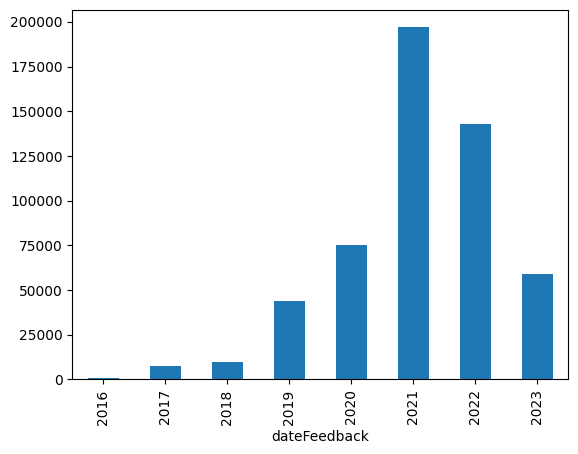

In [121]:
initiatives_df['feedbackStartDate'] = pd.to_datetime(initiatives_df['feedbackStartDate'])
initiatives_df['feedbackEndDate'] = pd.to_datetime(initiatives_df['feedbackEndDate'])

feedbacks_df['dateFeedback'] = pd.to_datetime(feedbacks_df['dateFeedback'])
feedbacks_df['dateFeedback'].dt.year.value_counts().sort_index().plot(kind='bar')

### Authors

Due to lack of unique identifier, it is not possible to define number of unique authors.
However, feedbacks are published by private and public entities, as well as individuals. Feedbacks can be analysed by type of author which is an obligatory field in the feedback form.

In [122]:
print('Most common user types of feedback writers:',feedbacks_df['userType'].value_counts().nlargest(5))
usertype_counts = feedbacks_df['userType'].value_counts()

px.bar(usertype_counts[usertype_counts!=1], log_y=True)

Most common user types of feedback writers: userType
EU_CITIZEN              310742
COMPANY                  37448
BUSINESS_ASSOCIATION     31724
NGO                      19869
OTHER                    12446
Name: count, dtype: int64


### Attachments

Feedback can be published with attachment. Some users write short version of their feedback and put their full opinion in the attachment.

In [123]:
print("Number of feedbacks without any attachment:", sum(feedbacks_df['attachments'].str.len()<=2))

Number of feedbacks without any attachment: 484435


In [124]:
print("Number of empty feedbacks:",feedbacks_df['feedback'].isnull().sum())

Number of empty feedbacks: 272786


It is possible that some authors put feedback text in the attachment, leaving a field for comment empty.

In [125]:
null_feedbacks = feedbacks_df[feedbacks_df['feedback'].isnull()]
print('Number of empty feedbacks with no attachment:',sum(null_feedbacks['attachments'].str.len()<=2))

Number of empty feedbacks with no attachment: 257592


There are many rows which do not contain feedback text and do not have attachment. It is possible that these feedbacks were removed from the site by the EC. 

### Filtering only English feedbacks

In [126]:
feedbacks_df_eng=feedbacks_df[feedbacks_df['language']=='EN']
df = feedbacks_df_eng[feedbacks_df_eng['feedback'].notnull()]
print("Number of not null feedbacks in english:", len(df))

Number of not null feedbacks in english: 68289


In [127]:
df_titled = df.merge(summary_df, how="left", left_on='publicationId', right_on= 'id')
df_titled_summed = df_titled.merge(initiatives_df, how="left", left_on='groupId', right_on= 'id')

print("Most feedbacked initiatives",df_titled_summed['shortTitle'].value_counts().nlargest(10))

Most feedbacked initiatives shortTitle
Legislation for plants produced by certain new genomic techniques                                     7684
Evaluation of the legislative framework for tobacco control                                           1943
Procedures for alerts and contact tracing of passengers identified through Passenger Locator Forms    1571
European Defence Fund and EU Defence Industrial Development Programme                                  848
Establishing the digital euro                                                                          728
2030 Climate Target Plan                                                                               625
Extension of the list of EU crimes to hate speech and hate crime                                       582
Revision of the Renewable Energy Directive (EU) 2018/2001                                              547
Climate Law                                                                                            54

## Text Statistics

Conducting tokenization and lemmatization

In [128]:
data = df_titled_summed.copy()
data['tokenized'] = data['feedback'].apply(word_tokenize)

In [129]:
wnl = WordNetLemmatizer()
data['lemmatized'] = data['tokenized'].apply(lambda word_list: [wnl.lemmatize(word) for word in word_list])

### Number of words in feedback

Numbers of words will be presented for 2 subgroups: All feedbacks, and feedbacks without attachments. Because sometimes people place feedback in attachment and put only a short version in the field (or information about attachment), so it can mispresent the number of words in feedback.

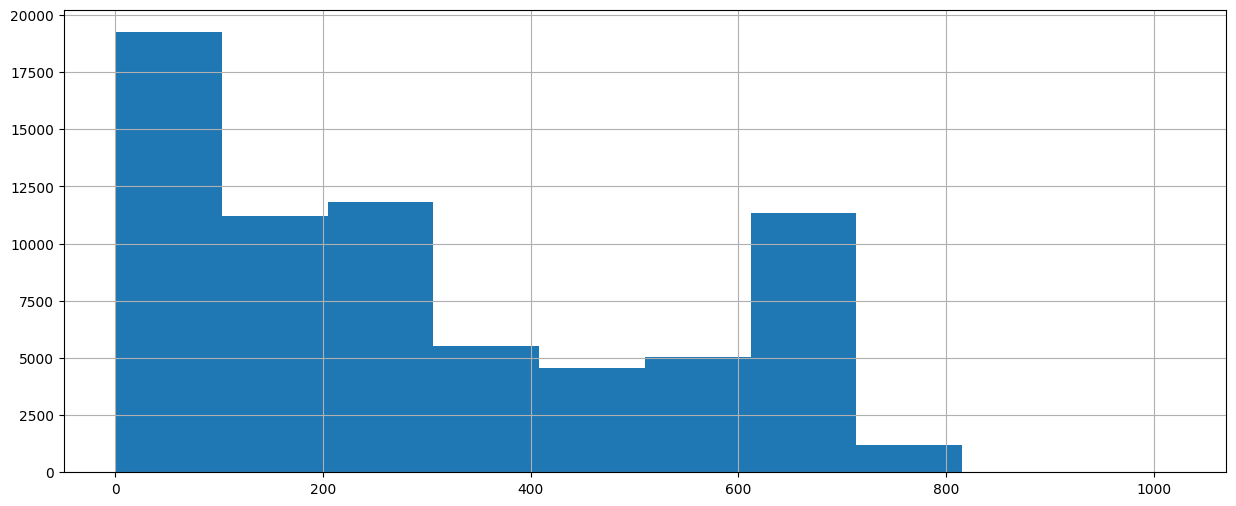

In [130]:
plt.figure(figsize=(15,6))
data['length']=data['lemmatized'].str.len()
data['length'].hist()
plt.show()


There is only one feedback longer than 1000 words.

In [131]:
data[data['length']>1000]

,language,id_x,country,organization,status,surname,firstName,feedback,userType,companySize,...,reference,id,shortTitle,foreseenActType,topics,feedbackStartDate,feedbackEndDate,tokenized,lemmatized,length
30054,EN,3378155,BEL,EGEC (European Geothermal Energy Council),PUBLISHED,Martini,Emil,"As EGEC, the voice of the European geothermal ...",NGO,MICRO,...,Ares(2022)6872695,13260.0,Communication on revamping the SET Plan,COMMUNIC,"[{'code': 'RESEARCH', 'label': 'Research and i...",2022-10-05 11:56:00,2022-11-02 23:59:59,"[As, EGEC, ,, the, voice, of, the, European, g...","[As, EGEC, ,, the, voice, of, the, European, g...",1019


There is a group of feedbacks which have more than 800 words. There is 27 of such feedbacks.

In [132]:
print("Number of feedbacks longer than 800 words:",len(data[data['length']>800][['shortTitle', 'feedback','country', 'userType', 'topics', 'length']]))

Number of feedbacks longer than 800 words: 27


Divided by having attachment or not

In [133]:
data['has_attachment']=data['attachments'].str.len()<=2

In [134]:
px.histogram(data,x='length', facet_row='has_attachment')

The shape of the distribution of length in 2 groups (with and without attachments) is similar, but the distribution of feedbacks without attachment is flatter.

## Differences in feedback length between user types

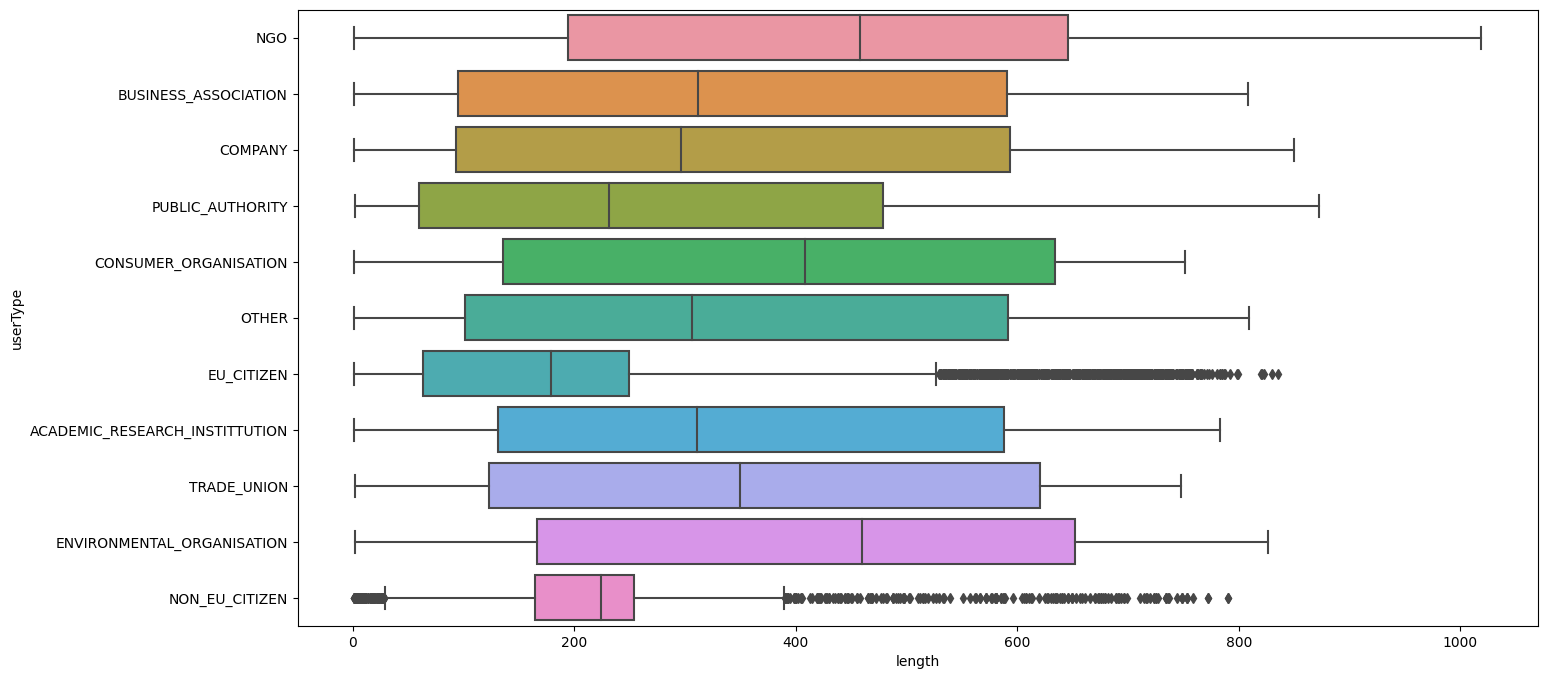

In [135]:
plt.figure(figsize=(16, 8))
sns.boxplot(y='userType', x='length', data=data)
plt.show()

Length of feedbacks by country

In [136]:
most_common_countries=list(country_counts[country_counts>=1000].index)
data['if_common_country']=data['country'].apply(lambda x: True if x in most_common_countries else False)
data_common_countries = data[data['if_common_country']==True]

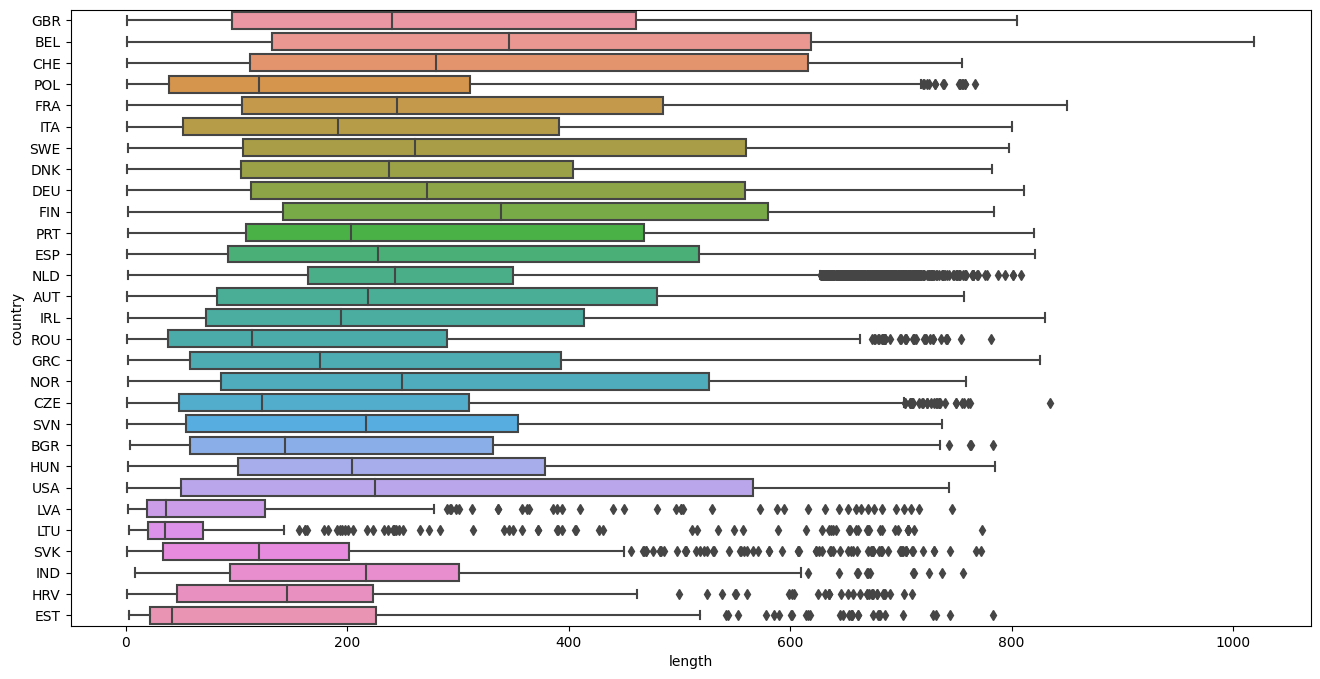

In [137]:
data 
plt.figure(figsize=(16, 8))
sns.boxplot(y='country', x='length', data=data_common_countries)
plt.show()

Only countries where was more than 1000 feedbacks were ploted.

# Most common words

## Lemmatization

In [138]:
stop_words = set(stopwords.words('english'))
data['lemmatized_no_stop'] = data['tokenized'].swifter.apply(lambda word_list: [wnl.lemmatize(word.lower()) for word in word_list if word.lower() not in stop_words|set(string.punctuation) ])

Pandas Apply:   0%|          | 0/69963 [00:00<?, ?it/s]

In [139]:
def plot_counter(counter: Counter, orient: str = 'h', color: str='lightblue', figsize: tuple=(20,13)):
    plt.figure(figsize=figsize)
    keys = [k[0] for k in counter]
    vals = [int(k[1]) for k in counter]
    ax = sns.barplot(x=vals, y=keys, orient=orient, color=color)
    ax.bar_label(ax.containers[0])
    return ax

cv=CountVectorizer(tokenizer=lambda x:x, preprocessor=None, lowercase=False)
count_vector=cv.fit_transform(data['lemmatized_no_stop'].values)
word_counts=count_vector.sum(axis=0)
word_freq = [(ngram, word_counts[0, idx])
              for ngram, idx in cv.vocabulary_.items()]
word_freq = sorted(word_freq, key = lambda x: x[1], reverse=True)

c:\Users\jukucz\AppData\Local\miniconda3\lib\site-packages\sklearn\feature_extraction\text.py:528: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



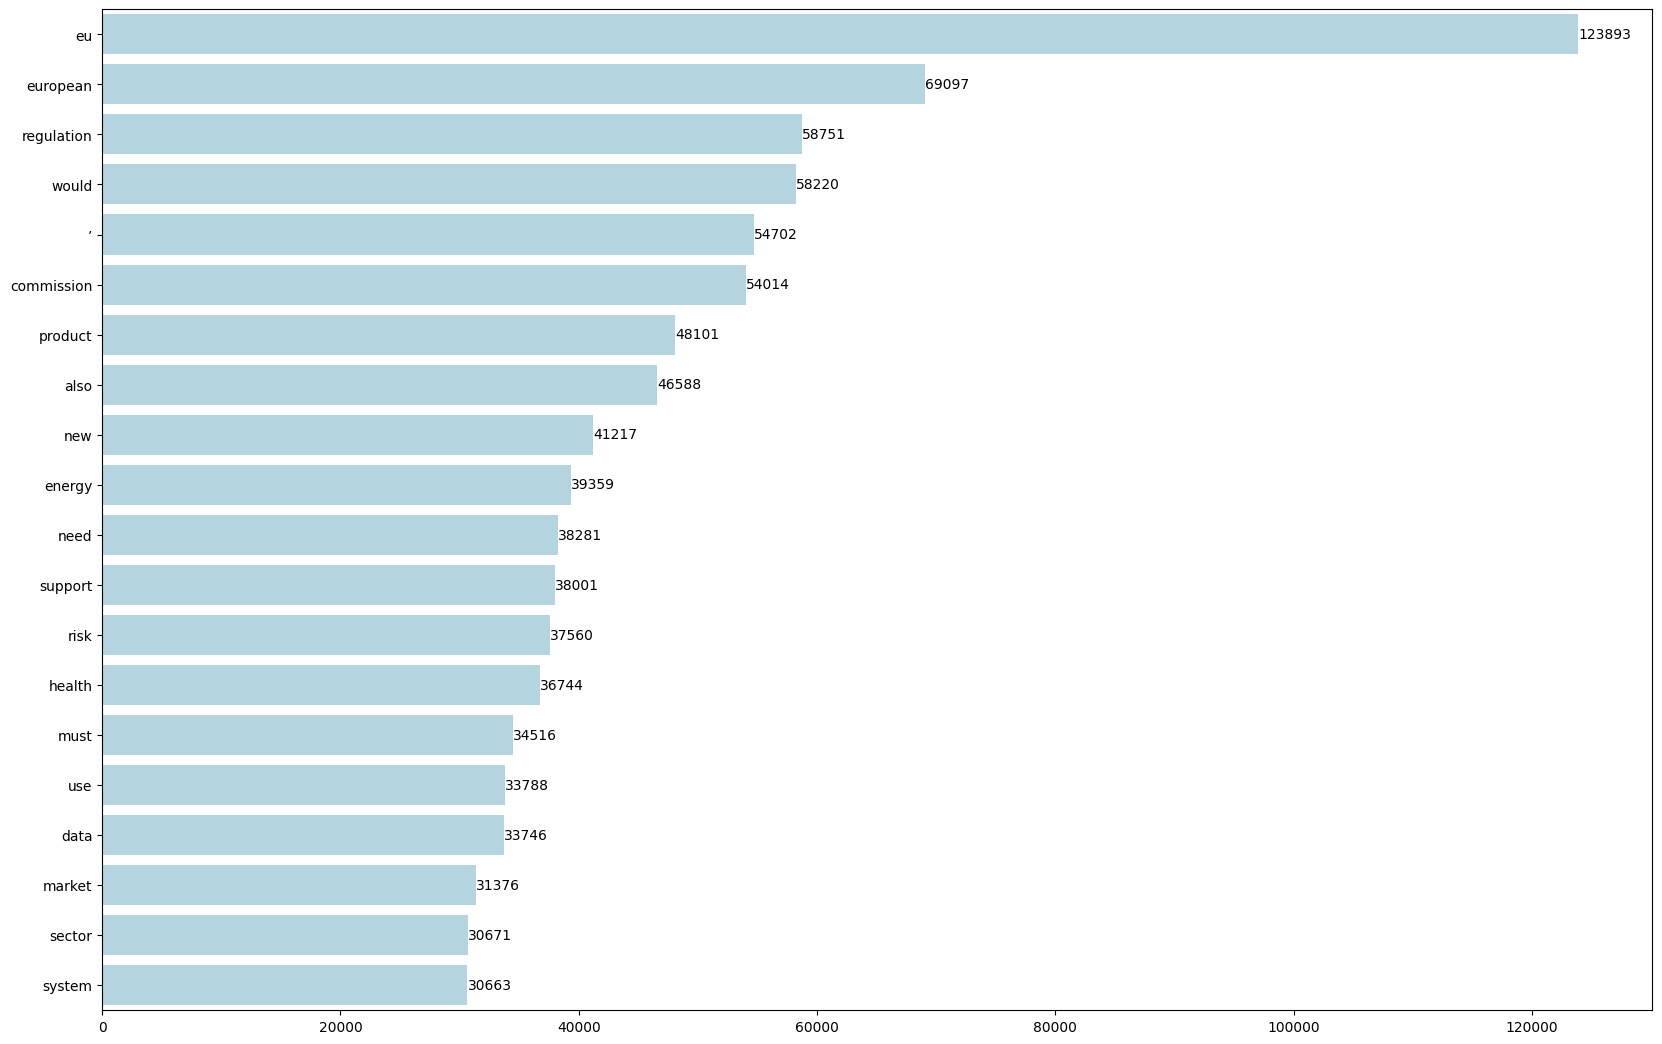

In [140]:
plot_counter(word_freq[:20])
plt.show()

In the most common words plotted above, there is many stop words, which were not removed by the process. Lemmatization must be repeated with custom list of stop words concatenated with the standard one.
Also, words like: 'european' and 'europe' will be removed, because they are not informative and their presence is caused by the fact that the feedbacks are about European Union.

In [141]:
custom_stop_words = set(['’','would','eu','european', 'must', 'also', 'europe','•','“','”'])| stop_words|set(string.punctuation)
data['lemmatized_no_stop'] = data['tokenized'].swifter.apply(lambda word_list: [wnl.lemmatize(word.lower()) for word in word_list if word.lower() not in custom_stop_words])

Pandas Apply:   0%|          | 0/69963 [00:00<?, ?it/s]

In [142]:
cv=CountVectorizer(tokenizer=lambda x:x, preprocessor=None, lowercase=False)
count_vector=cv.fit_transform(data['lemmatized_no_stop'].values)
word_counts=count_vector.sum(axis=0)
word_freq = [(ngram, word_counts[0, idx])
              for ngram, idx in cv.vocabulary_.items()]
word_freq = sorted(word_freq, key = lambda x: x[1], reverse=True)

c:\Users\jukucz\AppData\Local\miniconda3\lib\site-packages\sklearn\feature_extraction\text.py:528: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



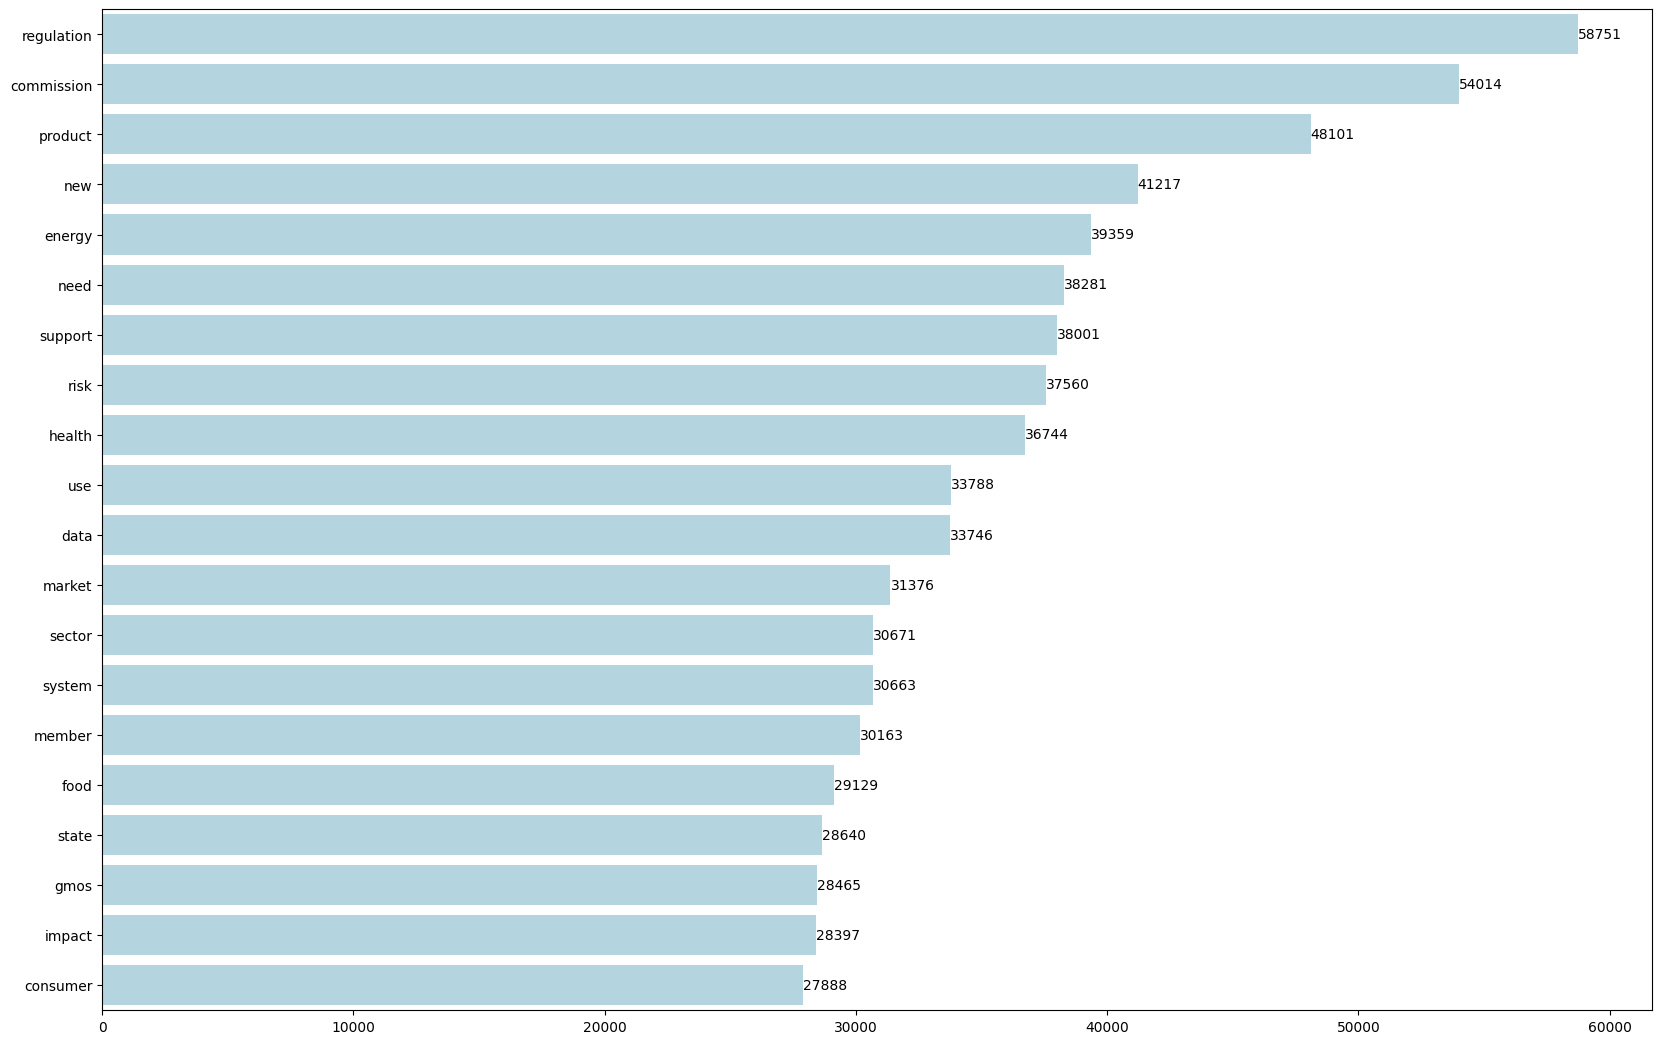

In [143]:
plot_counter(word_freq[:20])
plt.show()

## Most common words specific for user types


In [144]:
# Data preparation to plot numerosities of common words for each user type.
userTypes = data['userType'].dropna().unique()

types_counter = {}
for user in userTypes:
    data_user = count_vector[data['userType'] == user]
    user_word_counts=data_user.sum(axis=0)
    user_word_freq = [(word, user_word_counts[0, idx])
                for word, idx in cv.vocabulary_.items()]
    user_word_freq = sorted(user_word_freq, key = lambda x: x[1], reverse=True)
    types_counter[user]=user_word_freq


data['length_no_stop']=data['lemmatized_no_stop'].apply(len)
most_common_words = set()
user_all_words_length =dict()
for ut in userTypes:
    types_best = Counter(types_counter.get(ut)).most_common(5)
    for pair,_ in types_best:
        most_common_words.add(pair[0])
    user_all_words_length[ut] = data[data['userType']==ut]['length_no_stop'].sum()

most_common_words = sorted(list(most_common_words))
most_common_words_ids = np.array(list(map(cv.vocabulary_.get, most_common_words)))
d = {}
for user in userTypes:
    data_user = count_vector[data['userType'] == user]
    user_word_counts=data_user.sum(axis=0).reshape(-1)
    word_counts = user_word_counts.A1[most_common_words_ids]
    d[user]=word_counts

most_common_counted = pd.DataFrame(d, index=most_common_words)
users_most_df = most_common_counted.melt(ignore_index=False, var_name = 'userType', value_name='count').reset_index(names='word')

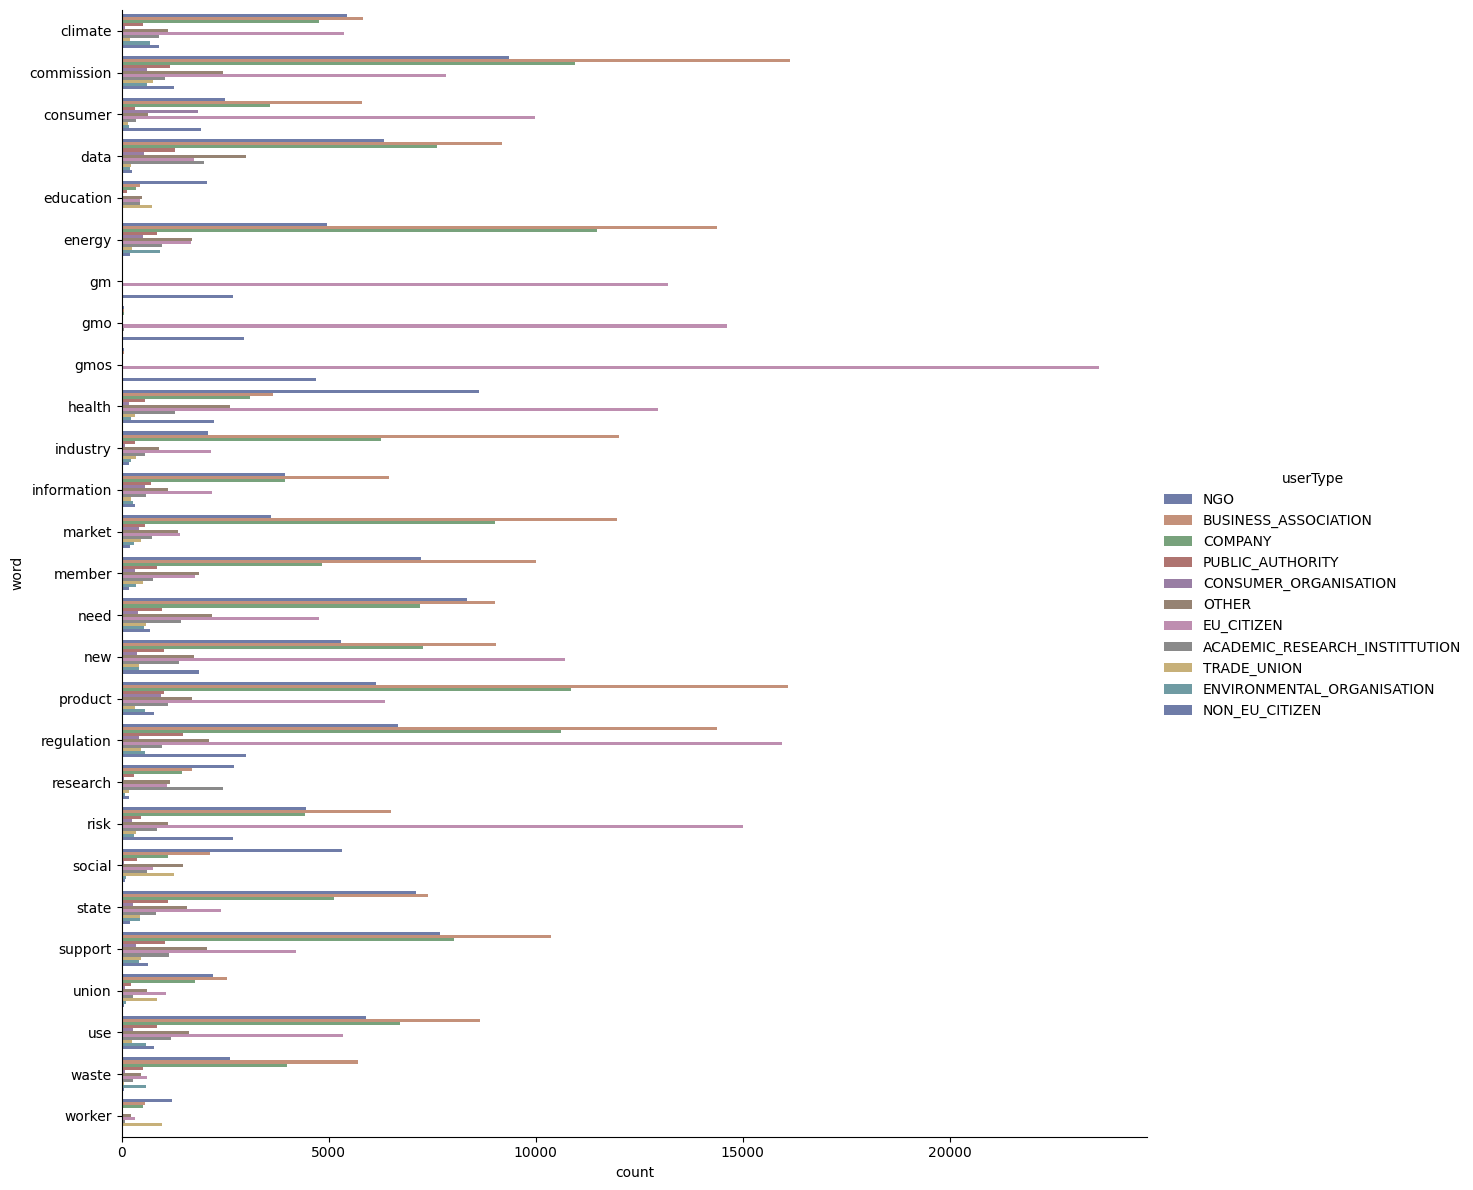

In [145]:
sns.catplot(
    data=users_most_df, kind="bar", y="word",
    x="count", hue="userType",
    palette="dark", alpha=.6, height=12, orientation="horizontal")
plt.show()


The number of feedbacks by each user type group differs. To normalize and compare the quantity of common words most common words will be presented in per milles. Number of words will be multiplied by 1000 and divided by number of words in feedbacks of user type group.

In [146]:
most_common_counted_standard = most_common_counted*1000/pd.Series(user_all_words_length)
users_most_df_standard = most_common_counted_standard.melt(ignore_index=False, var_name = 'userType', value_name='count').reset_index(names='word')

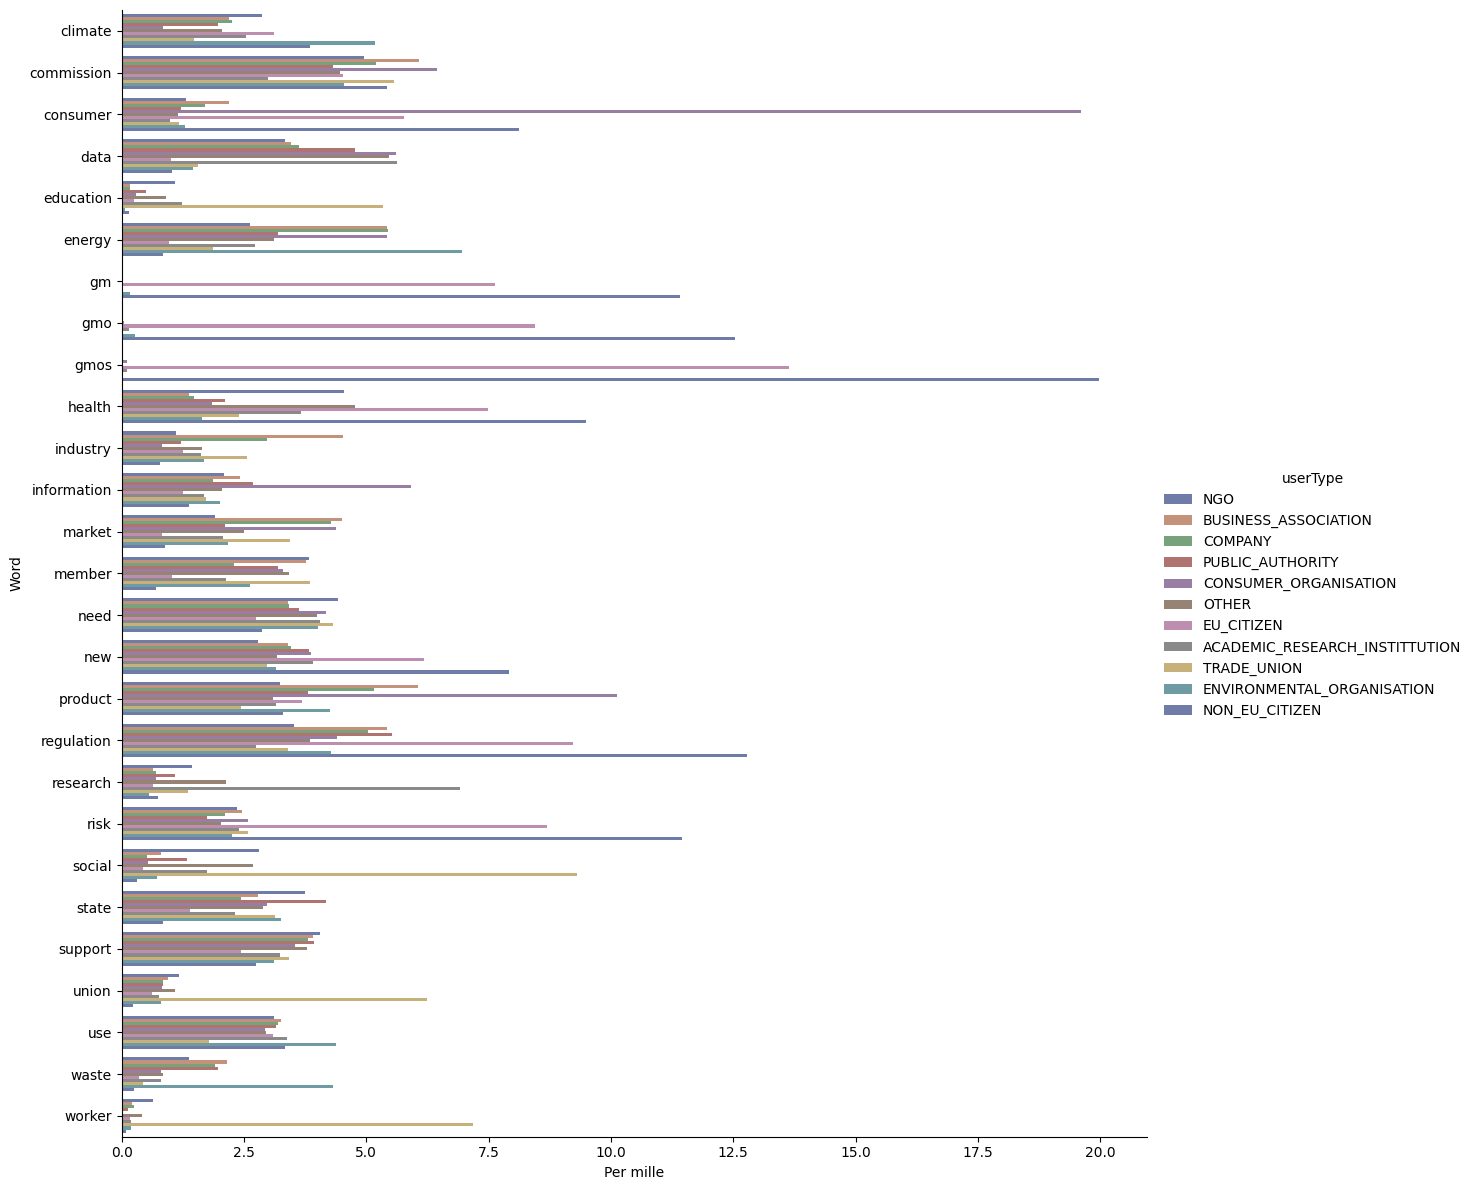

In [147]:
p = sns.catplot(
    data=users_most_df_standard, kind="bar", y="word",
    x="count", hue="userType",
    palette="dark", alpha=.6, height=12, orientation="horizontal"
)
p.set_axis_labels("Per mille", "Word")
plt.show()

## Common words by user type

Same ananlysis as above, but only for user type groups which have more than 5000 feedbacks.

In [148]:
pop_userType = ['EU_CITIZEN', 'BUSINESS_ASSOCIATION', 'COMPANY', 'NGO']

In [151]:
# Data preparation to plot numerosities of common words for each user type.
types_counter = {}
for user in pop_userType:
    data_user = count_vector[data['userType'] == user]
    user_word_counts=data_user.sum(axis=0)
    user_word_freq = [(word, user_word_counts[0, idx])
                for word, idx in cv.vocabulary_.items()]
    user_word_freq = sorted(user_word_freq, key = lambda x: x[1], reverse=True)
    types_counter[user]=user_word_freq
    
data['length_no_stop']=data['lemmatized_no_stop'].apply(len)
most_common_words = set()
user_all_words_length =dict()
for ut in userTypes:
    types_best = Counter(types_counter.get(ut)).most_common(5)
    for pair,_ in types_best:
        most_common_words.add(pair[0])
    user_all_words_length[ut] = data[data['userType']==ut]['length_no_stop'].sum()
most_common_words = sorted(list(most_common_words))
most_common_words_ids = np.array(list(map(cv.vocabulary_.get, most_common_words)))
d = {}
for user in pop_userType:
    data_user = count_vector[data['userType'] == user]
    user_word_counts=data_user.sum(axis=0).reshape(-1)
    word_counts = user_word_counts.A1[most_common_words_ids]
    d[user]=word_counts
most_common_counted = pd.DataFrame(d, index=most_common_words)
users_most_df = most_common_counted.melt(ignore_index=False, var_name = 'userType', value_name='count').reset_index(names='word')

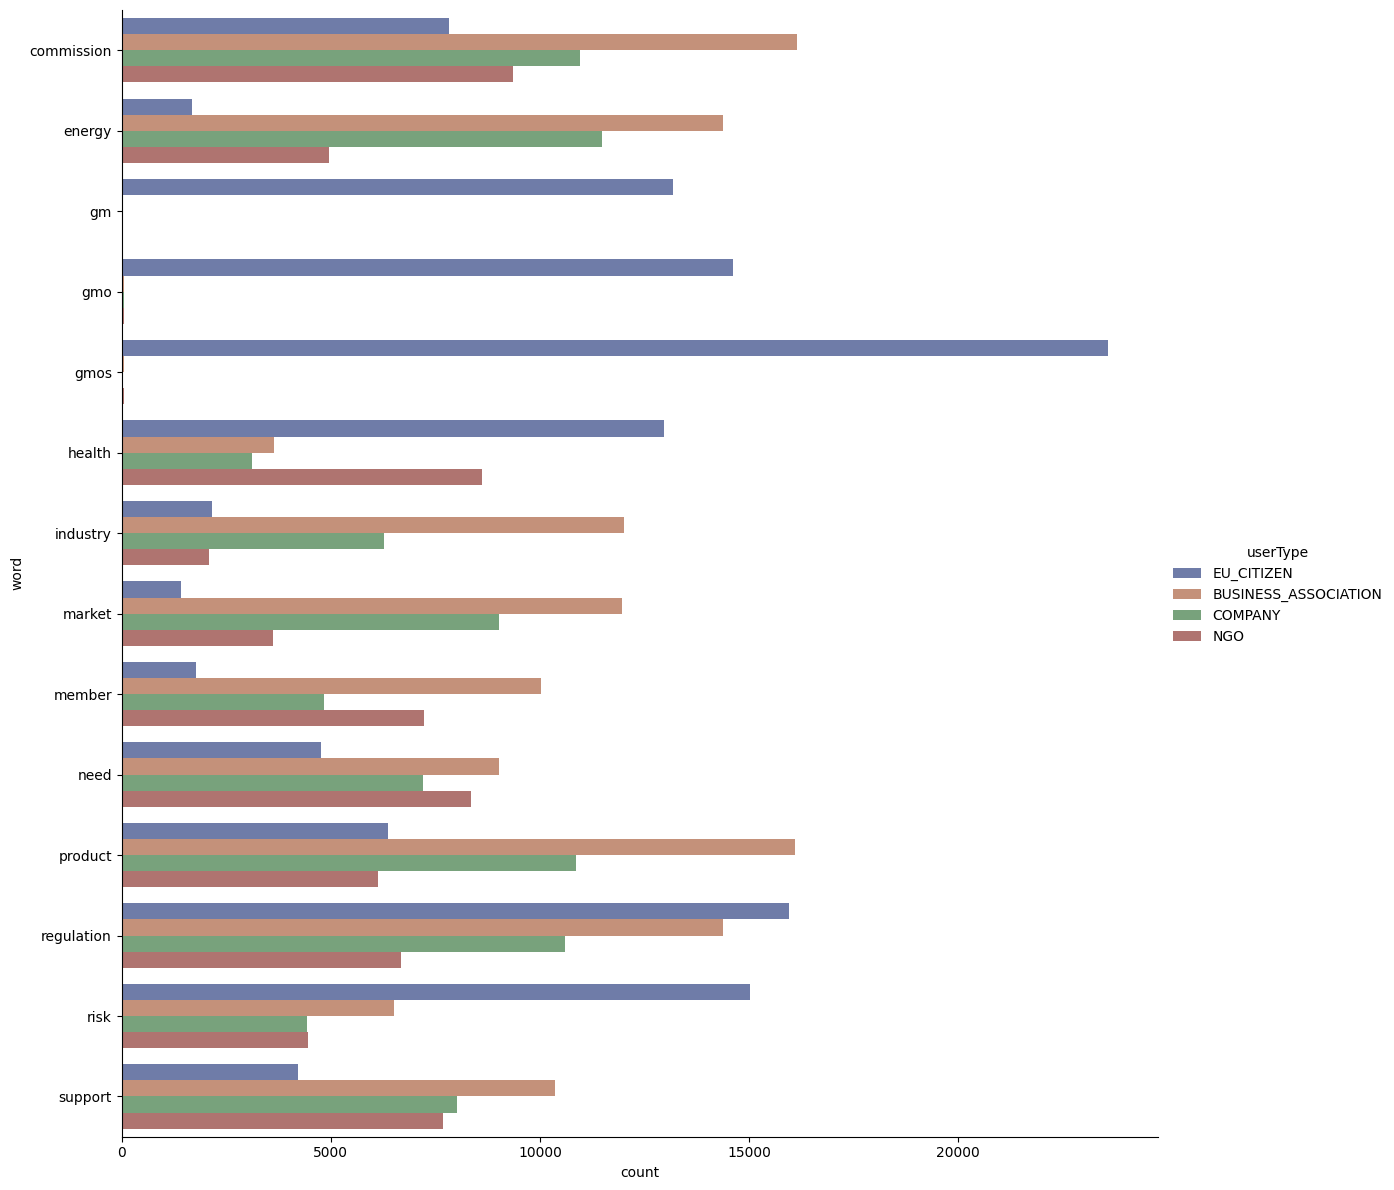

In [150]:
sns.catplot(
    data=users_most_df, kind="bar", y="word",
    x="count", hue="userType",
    palette="dark", alpha=.6, height=12, orientation="horizontal"
)
plt.show()


# Topic modelling

In [152]:
from gensim.corpora.dictionary import Dictionary
from gensim.models.ldamulticore import LdaMulticore
import pyLDAvis.gensim_models

In [153]:
dictionary = Dictionary(data['lemmatized_no_stop'])
encoded_docs = data['lemmatized_no_stop'].apply(dictionary.doc2bow)
lda = LdaMulticore(encoded_docs, num_topics=15)
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda, encoded_docs, dictionary=dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
10     0.013689  0.019701       1        1  13.976486
1     -0.015048 -0.024486       2        1  11.351171
5      0.013823  0.026124       3        1  10.407745
11     0.038244  0.002606       4        1   9.987908
13    -0.003143 -0.016874       5        1   9.392035
14     0.006518 -0.013772       6        1   8.240802
4      0.004958  0.003384       7        1   7.254450
3      0.005258 -0.016452       8        1   5.660154
7      0.015390 -0.002840       9        1   5.052908
2      0.004735 -0.017826      10        1   4.829179
12     0.001123 -0.003530      11        1   4.091308
6     -0.007145  0.024153      12        1   3.483833
9     -0.048182  0.012415      13        1   2.855115
0     -0.006051  0.004919      14        1   2.224380
8     -0.024169  0.002477      15        1   1.192525, topic_info=            Term          Freq         Total Category  logprob  loglift
2784      energy  42766.000000  42766.000000  Default  30.0000  30.0000
2475          de  11000.000000  11000.000000  Default  29.0000  29.0000
249   commission  52649.000000  52649.000000  Default  28.0000  28.0000
141      product  46034.000000  46034.000000  Default  27.0000  27.0000
746         data  41304.000000  41304.000000  Default  26.0000  26.0000
...          ...           ...           ...      ...      ...      ...
161   regulation    364.309167  51805.932241  Topic15  -5.8582  -0.5282
88        impact    288.804513  28115.484799  Topic15  -6.0904  -0.1492
427        state    285.302764  29897.422228  Topic15  -6.1026  -0.2229
202      welcome    267.088611  22938.720271  Topic15  -6.1686  -0.0239
171         risk    269.757973  33511.296972  Topic15  -6.1587  -0.3930

[1451 rows x 6 columns], token_table=       Topic      Freq Term
term                       
726        1  0.255017   ''
726        2  0.068593   ''
726        3  0.100388   ''
726        4  0.126916   ''
726        5  0.089460   ''
...      ...       ...  ...
354       12  0.029818    –
354       13  0.028371    –
354       14  0.018727    –
354       15  0.008118    –
50845     14  0.622979   ️️

[7845 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[11, 2, 6, 12, 14, 15, 5, 4, 8, 3, 13, 7, 10, 1, 9])

# Finding charasteristic terms and their associations with user types

For that purpose only data from 2 most common userTypes: EU-citizen and company was filtered. I also filtered out feedbacks with attachments, because they are not representative of full texts of the feedback.

In [106]:
import scattertext as st
import spacy
import pickle

In [105]:
df['userType'].value_counts()

userType
EU_CITIZEN                        18190
BUSINESS_ASSOCIATION              14866
COMPANY                           11999
NGO                                8417
OTHER                              3041
NON_EU_CITIZEN                     2118
ACADEMIC_RESEARCH_INSTITTUTION     1928
PUBLIC_AUTHORITY                   1798
TRADE_UNION                         686
ENVIRONMENTAL_ORGANISATION          616
CONSUMER_ORGANISATION               460
Name: count, dtype: int64

In [103]:
df_filtered = df[df['userType'].isin(['EU_CITIZEN', 'COMPANY'])].copy()
df_filtered['has_attachment']=df_filtered['attachments'].str.len()<=2
df_filtered2 = df_filtered[df_filtered['has_attachment']==True]


In [104]:
nlp = spacy.load('en_core_web_sm')
corpus = st.CorpusFromPandas(df_filtered2, category_col='userType', text_col='feedback', nlp=nlp).build()

In [107]:
corpus_pickled = pickle.dump(corpus, open('corpus.pkl', 'wb'))

10 terms which differentiate the corpus (words in feedbacks from eu-citizens and companies) from ageneral language corpus:

In [108]:
corpus_no_stop =corpus.get_stoplisted_unigram_corpus()

In [109]:
print(list(corpus_no_stop.get_scaled_f_scores_vs_background().index[:10]))

['gmos', 'gmo', 'biodynamic', 'traceability', 'labelling', 'traceable', 'genomic', 'weakening', 'precautionary', 'farming']


Most of words above is associated with biotechnology, e.g. 'gmos'/'genomic'/'farming'.

## 10 terms characteristic for eu-citizens:

In [110]:
term_freq_df = corpus_no_stop.get_term_freq_df()
term_freq_df['EU_CITIZEN Score'] = corpus_no_stop.get_scaled_f_scores('EU_CITIZEN')
term_freq_df['COMPANY Score'] = corpus_no_stop.get_scaled_f_scores('COMPANY')

In [111]:
list(term_freq_df.sort_values(by='EU_CITIZEN Score', ascending=False).index[:10])

['deregulate',
 'biodynamic',
 'gmos',
 'gm',
 'traceable',
 'gmo',
 'ruling',
 'weakening',
 'harvests',
 'engineered']

## 10 terms characteristic for companies:

In [112]:
list(term_freq_df.sort_values(by='COMPANY Score', ascending=False).index[:10])

['welcomes',
 'h2',
 'adca',
 'titanium',
 'decarbonisation',
 'citrus',
 'supports',
 'believes',
 'tio2',
 'gases']

## Plotting characteristic terms by selected user types

In [114]:
html = st.produce_scattertext_explorer(corpus_no_stop,
         category='EU_CITIZEN',
         category_name='EU Citizen',
         not_category_name='Company',
         width_in_pixels=1000)
open("vis.html", 'wb').write(html.encode('utf-8'))

35181553

The plot is available in the seperate file: vis.html. Please open it in the browser. It may take a few minutes to load and display the plot.

# Conclusions

- This notebook is only the beginning of the analysis neccessary to discover the properties of the corpus.
- There is a lot of feedbacks which are not in English, but have English tag in the metadata. Because of that, the results of analysis may not be informative. For any further analysis it is neccessary to conduct language detection and further data cleaning.
- Only English feedbacks were analysed, analysis of other languages is a possible subject for further research.
- In the data there is some inconsistencies, e.g. some feedbacks have no text, but have attachment, some have text and attachment, some have only text. In this notebook only information about existence of attachment was used, but the content of attachments was not analysed.